In [40]:
from langgraph.graph import StateGraph, START , END
from typing_extensions import TypedDict , Literal

In [41]:
class Quadratic_equation(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant : float
    roots : str
    

In [42]:
def show_equation(state: Quadratic_equation) -> str:
    eq =  f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'
    return {'equation': eq}

In [43]:
def discriminant_cal(state: Quadratic_equation) -> float:
    dis = state['b']**2 - 4*state['a']*state['c']
    return {'discriminant': dis}

In [44]:
def no_roots(state: Quadratic_equation) -> str:
    return {'roots': 'No real roots'}

def one_root(state: Quadratic_equation) -> str:
    root = -state['b'] / (2 * state['a'])
    return {'roots': f'One real root: {root}'}

def two_roots(state: Quadratic_equation) -> str:
    root1 = (-state['b'] + state['discriminant']**0.5) / (2 * state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2 * state['a'])
    return {'roots': f'Two real roots: {root1} and {root2}'}

In [45]:
def routing(state: Quadratic_equation) -> Literal['no_roots' , 'One_root' , 'Two_roots']:
    if state['discriminant'] > 0:
        return 'Two_roots'
    elif state['discriminant'] == 0:
        return 'One_root'
    else:
        return 'no_roots'

In [46]:
graph = StateGraph(Quadratic_equation)

graph.add_node('Equation', show_equation)
graph.add_node('Discriminant', discriminant_cal)
graph.add_node('no_roots', no_roots)
graph.add_node('One_root', one_root)
graph.add_node('Two_roots', two_roots)

graph.add_edge(START, 'Equation')
graph.add_edge('Equation', 'Discriminant')
graph.add_conditional_edges('Discriminant', routing)
graph.add_edge('no_roots', END)
graph.add_edge('One_root', END)
graph.add_edge('Two_roots', END)

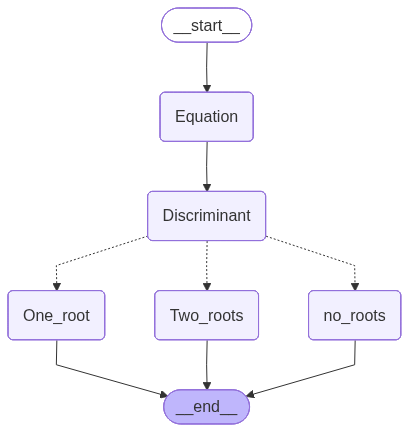

In [47]:
graph_builder = graph.compile()

graph_builder

In [59]:
graph_builder.invoke({
    'a': 2,
    'b': 4,
    'c': 2
})

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 + 4x + 2',
 'discriminant': 0,
 'roots': 'One real root: -1.0'}